In [34]:
library(ggplot2)
library(foreach)

library(Matrix)

library(foreach)
library(cowplot)
library(geometry)
library(cmaes)
library(DiceDesign)
library(orthopolynom)
library(viridis)

In [35]:
options(repr.plot.width = 14, repr.plot.height = 8) # size of plots


parallel = TRUE #if parallel computation (only related to optimization of hyperparameters)
if(parallel){
    library(doMC)
    n_batch = 5
    registerDoMC(cores = n_batch)
    }

save_data = TRUE #if data needs to be saved

optim = FALSE # if optimization of hyperparameters

noise = 0 #observation noise
if(noise == 0){ # adapt the path depending on the noise (first or second scenario)
    save_path = "first_scenario/"
}else{
    save_path = "second_scenario/"
}

compare_time_duration = FALSE

### Load the needed function

In [36]:

source("../utils_matrix_triangu.R") 
source("utils_triangu.R")
source("../utils_plot.R")
source("../utils_splines.R")
source("../utils_harmonics.R")


### Build triangulation  

In [37]:
jacob = jacob_sphere # indicate that we work with the Jacobian matrix associated to the spherical coordinates
set.seed(13)
list_tri = build_triangu(radius = 1,n_theta = 80, n_phi = 80) # build triangulation with 6400 points

design = lhsDesign(10, 2, seed=306)$design # LHS design 
design = maximinESE_LHS(design)$design # Maximin LHS

design[,1] = design[,1]*180
design[,2] = design[,2]*360

dist2 = function(x1,x2){return(sum((x1-x2)^2))}

if(noise == 0){
    idx_obs = apply(design, 1, function(x){which.min(apply(list_tri$points_2d,1, function(y){dist2(x,y)}))}) # Find the closest points in the triangulation
    design = as.data.frame(list_tri$points_2d[idx_obs,]) # design is made of these triangulation points
    A = A_func(list_tri = list_tri, sparse = TRUE, all_in_tri = TRUE, idx_obs  = idx_obs) #compute projection matrix
}else{
    A = A_func(points_mes = design ,list_tri = list_tri, sparse = TRUE, all_in_tri = FALSE, parallel = parallel) #compute projection matrix
    }

colnames(design) = c("theta","phi") 
design = as.data.frame(design)

if(save_data){write.csv(design,paste(save_path , "design.csv", sep=""), row.names = FALSE)} #save design




### Test function

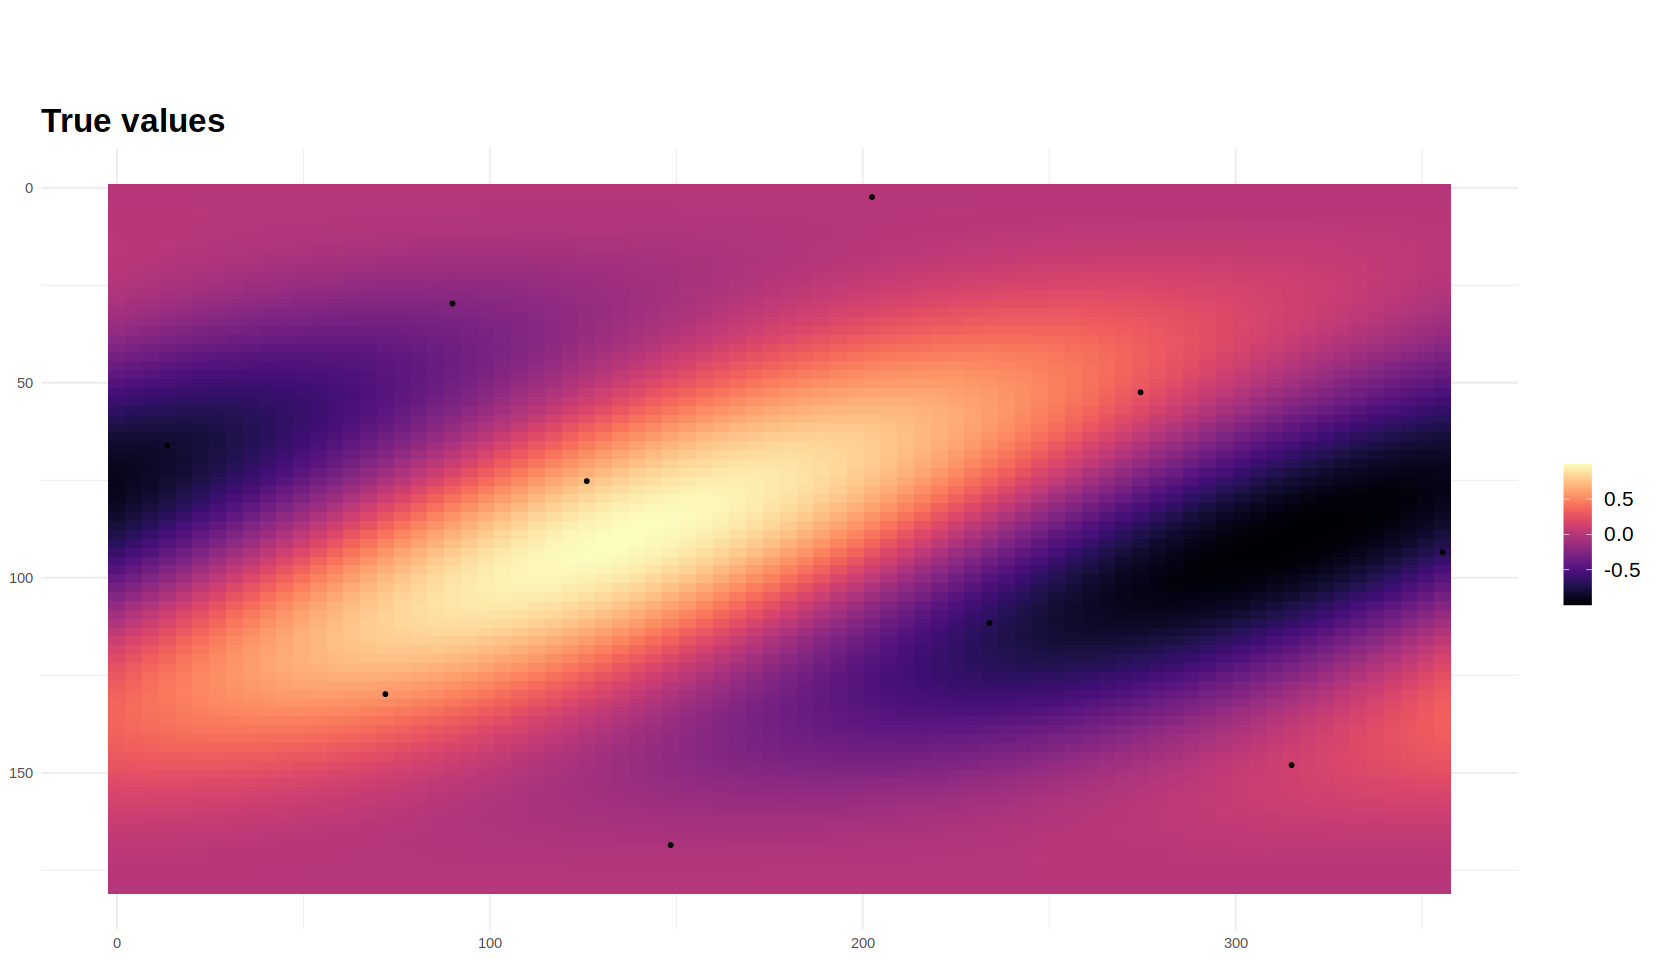

In [38]:
f_sphere = function(xx){
  x = sin(xx[1]*pi/180)*cos(xx[1]*pi/180)
  y = sin(xx[1]*pi/180)*sin(xx[1]*pi/180)
  z = cos(xx[1]*pi/180)
  r = sin(xx[1]*pi/180)^2
  return(cos(2*xx[1]*pi/180 + xx[2]*pi/180+pi/4)*r)
} # Analytical function to predict

df_test = list_tri$points_2d # The prediction points are the triangulation points
df_test$pred = apply(df_test, 1, f_sphere)

if(save_data){write.csv(df_test, paste(save_path , "df_test.csv", sep=""), row.names = FALSE)}


df_train = design 
df_train$y = apply(df_train,1,f_sphere) #compute values at observation points


plot_multiple_df(list(df_test), coords = c("phi","theta"), value = "pred", name = "", list_titles = c("True values"), ncol=1, list_opt = list(df_train[,c("phi","theta")],df_train[,c("phi","theta")]), add_fun = scale_y_reverse)

### Prediction with isotropic finite-element splines

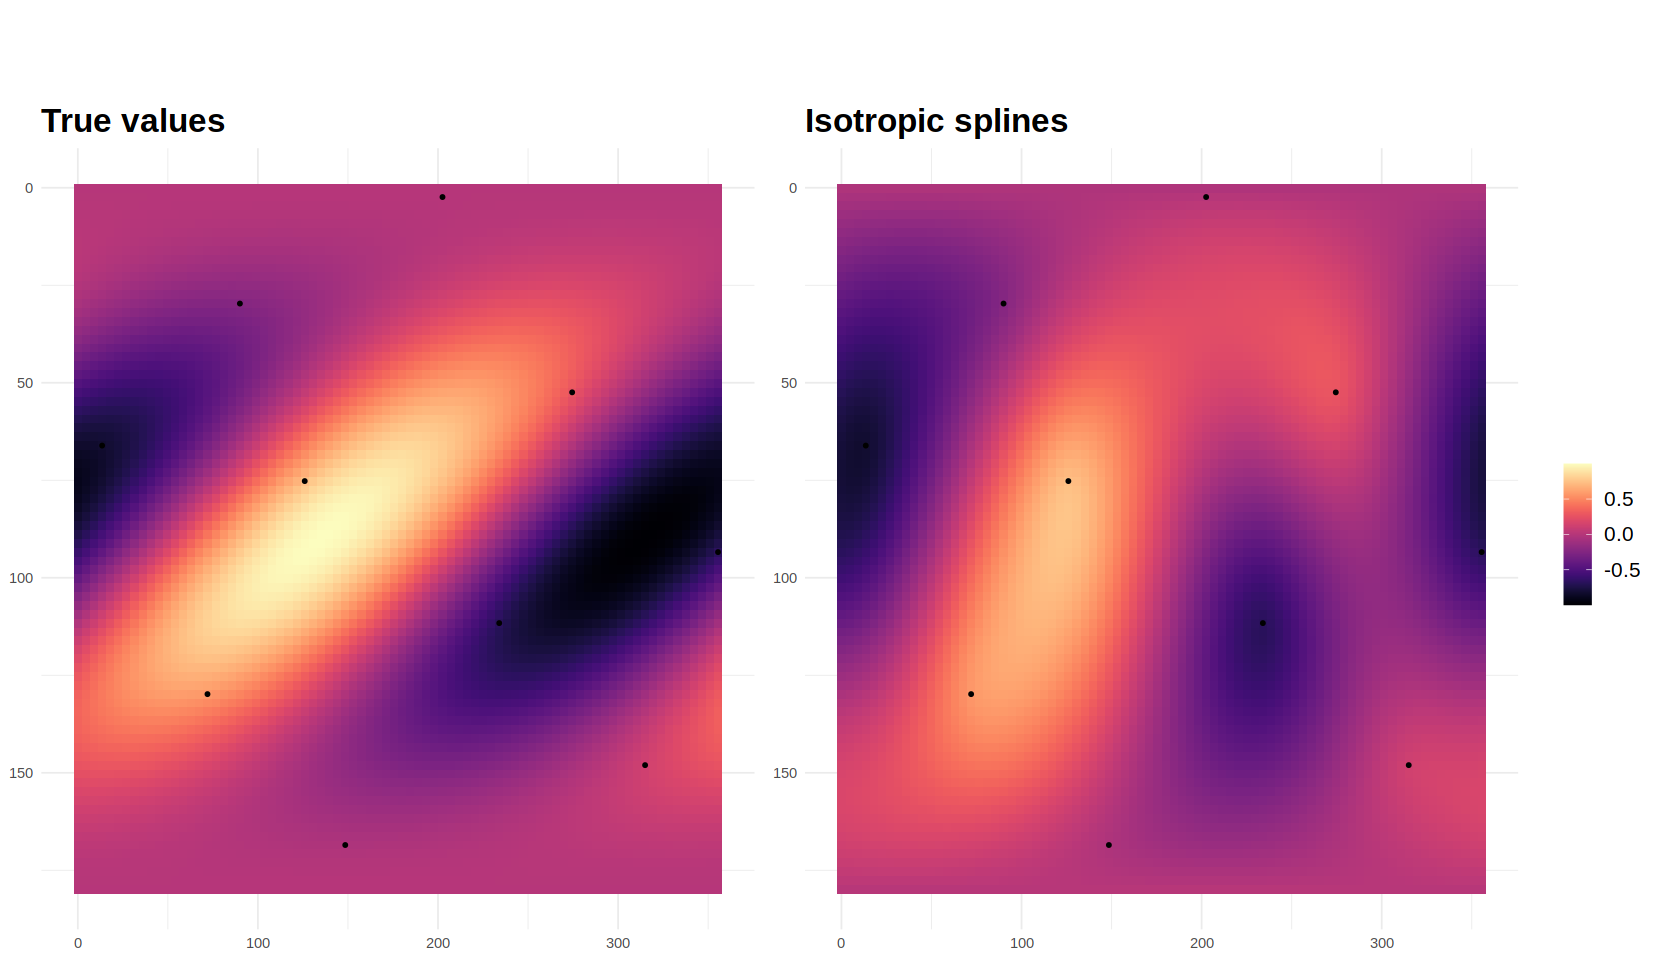

In [39]:
list_augmented = augmented_matrices(list_tri, var_a0 = NULL) #Compute matrices needed for the method: sqrt_M S^2 sqrt_M,  1/sqrt(alpha)(Mphi0), phi0, and alpha

var_a0 = list_augmented$var_a0 #return the computed alpha
pred_iso = pred_func(list_tri=list_tri,y = df_train$y, AA = A, idx_obs = idx_obs,list_augmented=list_augmented, noise = noise) #prediction at the triangulation points

df_pred_iso = cbind(list_tri$points_2d, pred_iso) # prediction matrix

colnames(df_pred_iso) = c("theta","phi","pred")

if(save_data){write.csv(df_pred_iso,  paste(save_path , "df_pred_iso.csv", sep=""), row.names = FALSE)}

plot_multiple_df(list(df_test, df_pred_iso), coords = c("phi","theta"), value = "pred", name = "", list_titles = c("True values", "Isotropic splines"), ncol=2, list_opt = list(df_train[,c("phi","theta")],df_train[,c("phi","theta")]), add_func = scale_y_reverse)


### Prediction with spherical harmonics

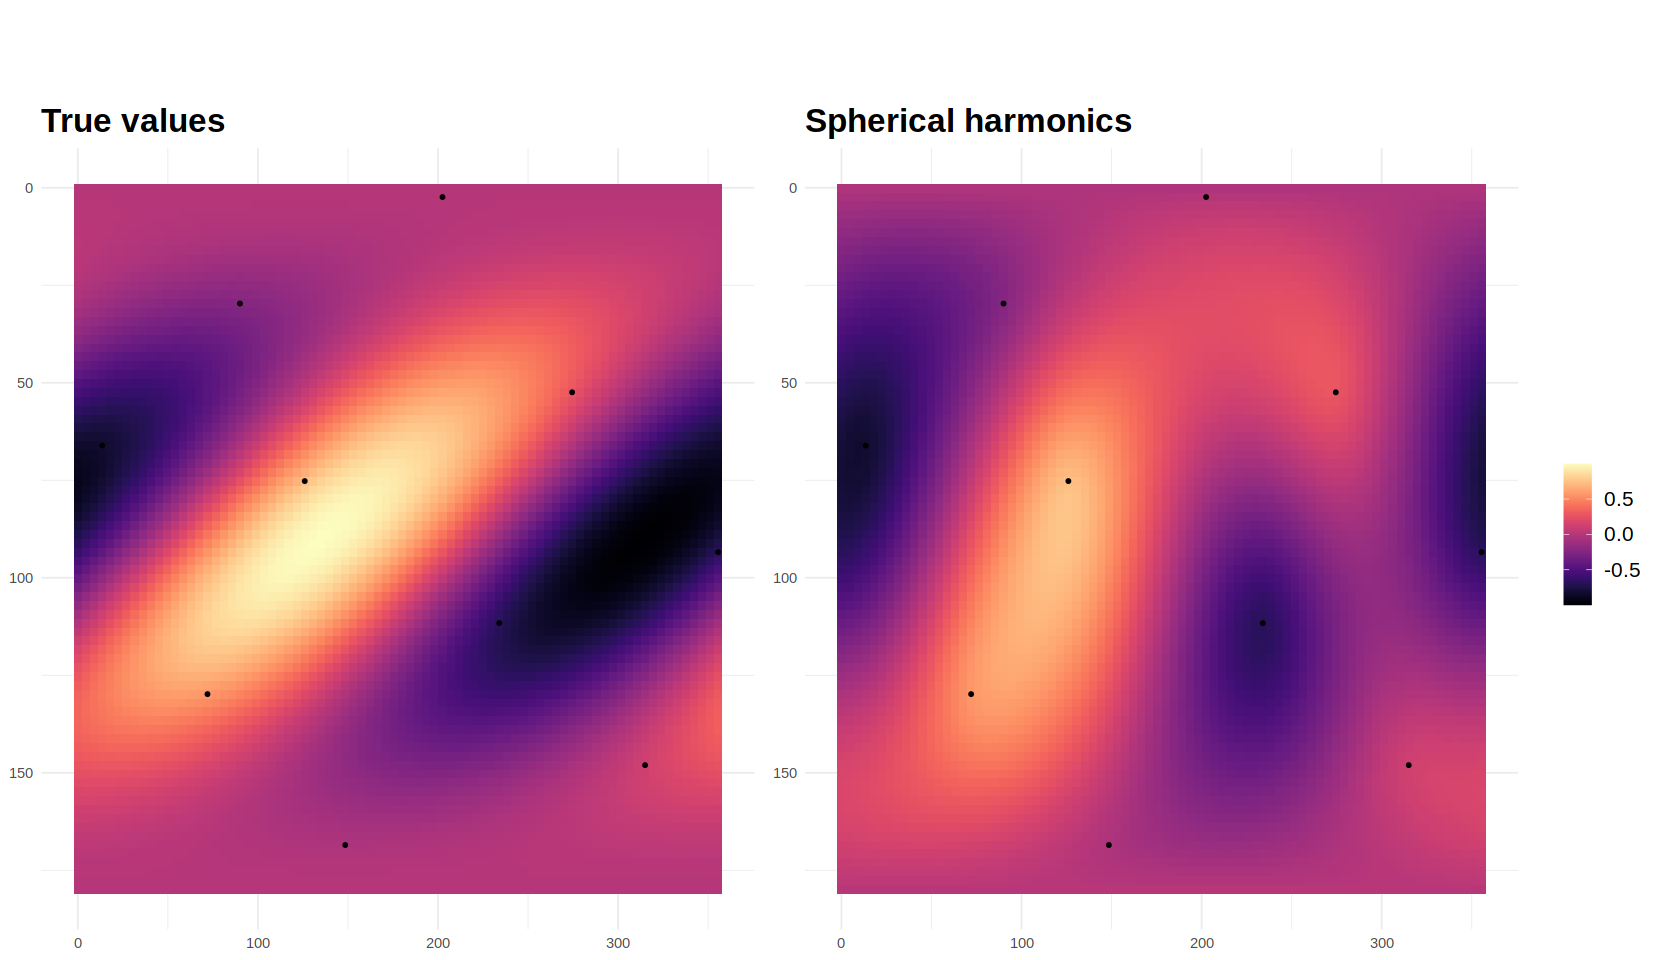

In [40]:
pred_harmo = pred_krig(df_obs = df_train, df_pred = list_tri$points_2d,Lmax = 40, noise = noise) # prediction with spherical harmonics

df_pred_harmo = cbind(list_tri$points_2d, pred_harmo) 
colnames(df_pred_harmo) = c("theta","phi","pred")

if(save_data){write.csv(df_pred_harmo, paste(save_path , "df_pred_harmo.csv", sep=""), row.names = FALSE)}

plot_multiple_df(list(df_test, df_pred_harmo), coords = c("phi","theta"), value = "pred", name = "", list_titles = c("True values", "Spherical harmonics"), ncol=2, list_opt = list(df_train[,c("phi","theta")],df_train[,c("phi","theta")]), add_func =  scale_y_reverse)

### Optimization of the anistropy parameters

In [41]:
if(optim){
    lambd = 5 # lambda in cmaes
    budget = 500 #budget for optimization: number of likelihood computations
    path = paste(save_path , "eval_cma.csv", sep="") 
    
    set.seed(10)
    
    fun=function(param){return(-ll_func(param, list_tri = list_tri, AA = A, y = df_train$y, var_a0 = var_a0, noise = noise, idx_obs = idx_obs))} #likelihood function
        
    f_vec <- function(X, save = TRUE){ #vectorize the likelihood function for parallel optimization, and save the results
        df_follow = as.matrix(read.csv(path))
        if(parallel){res = as.numeric(mclapply(1:ncol(X), function(i) fun(X[,i]), mc.cores = lambd))}
        else{res = as.numeric(sapply(1:ncol(X), function(i) fun(X[,i])))}                                
        if(save){write.csv(rbind(df_follow,cbind(t(X), res)), path, row.names = FALSE)}
      return(res)
    }
    
    write.csv(data.frame(t(rep(0, 4))), path, row.names = FALSE) #this csv file will contains all likelihood evaluations
    set.seed(10) 
    opt_cma=cma_es(par = c(pi/4,1,1), fn = f_vec, lower= c(0,0.01,0.01), upper =c(pi/2-0.01,20,20), control = list(maxit = budget%/%lambd, lambda = lambd,keep.best = TRUE, diag.pop=TRUE, diag.value = TRUE, sigma = 0.2, diag.sigma = TRUE, vectorized=TRUE)) # optimization with cmaes
    df_follow = as.matrix(read.csv(path))[-1,]
    psi_opt = as.numeric(df_follow[which.min(df_follow[,4]),1:3]) #get best parameters
    write.csv( data.frame(t(psi_opt)),  paste(save_path , "psi_opt.csv", sep="") , row.names = FALSE) #save best parameters

    }
                                                                
                                     

### Prediction with anisotropic finite-element splines

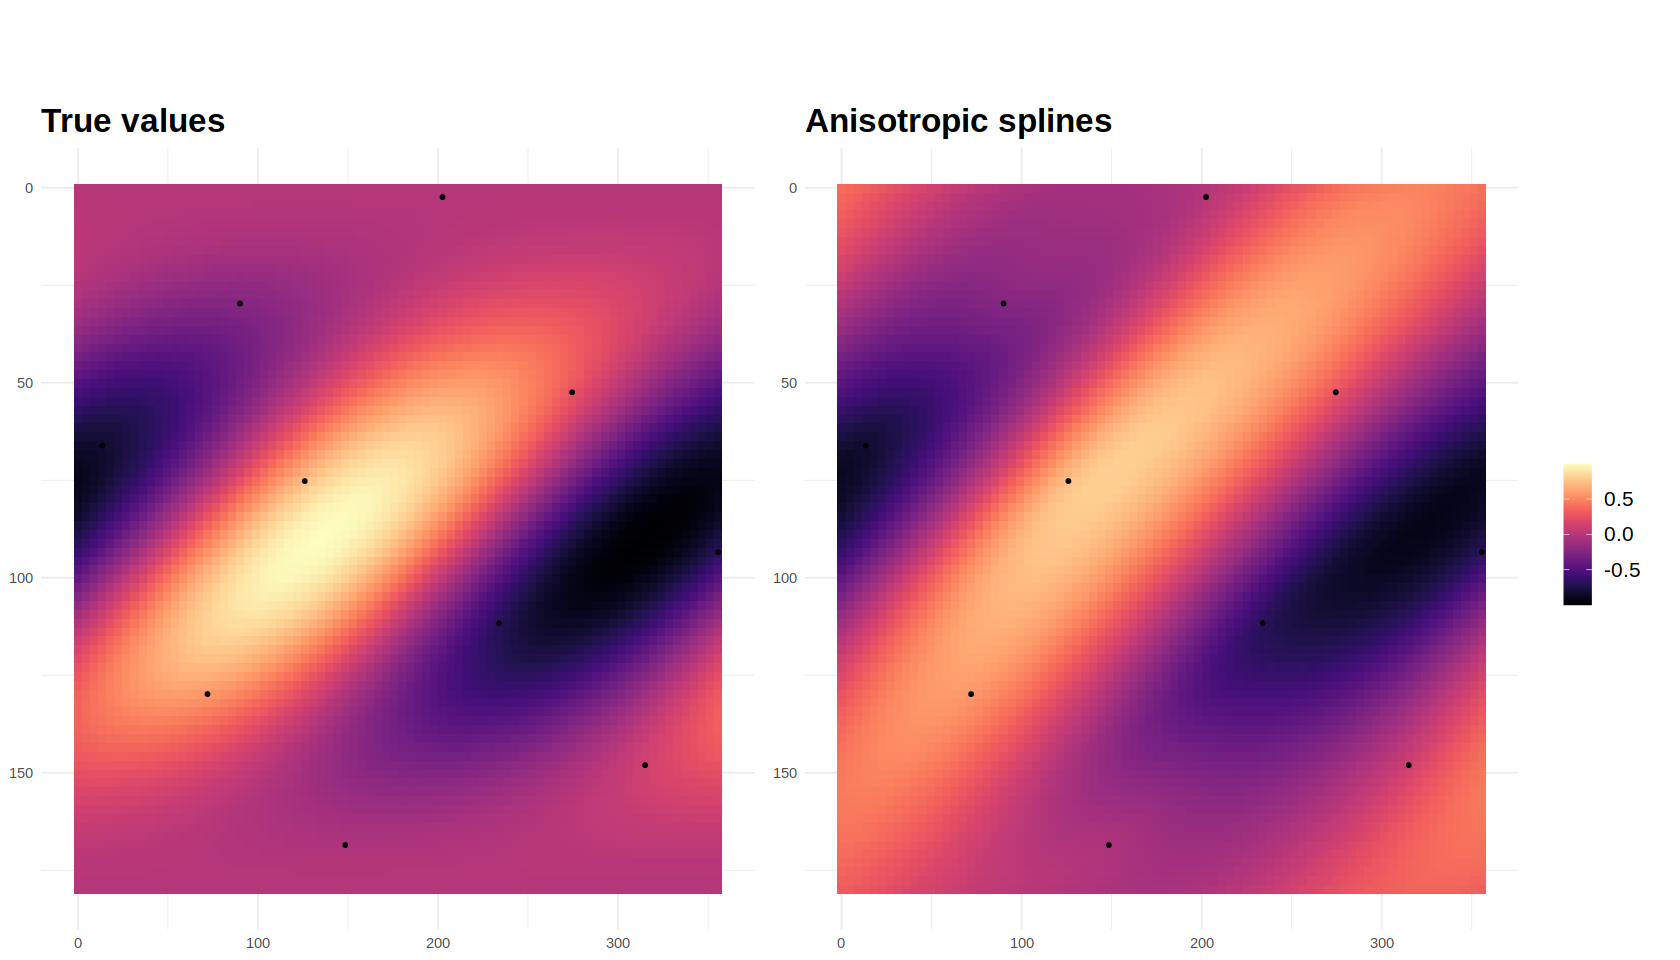

In [42]:
psi_opt = as.numeric(read.csv(  paste(save_path , "psi_opt.csv", sep=""))) #get best parameters

pred_aniso = pred_func(list_tri=list_tri,y = df_train$y, AA = A, idx_obs = idx_obs, theta = psi_opt[1], rho = psi_opt[2:3], var_a0 = var_a0, noise = noise) #anisotropic prediction

df_pred_aniso = cbind(list_tri$points_2d, pred_aniso)

colnames(df_pred_aniso) = c("theta","phi","pred")

if(save_data){write.csv(df_pred_aniso, file =  paste(save_path , "df_pred_aniso.csv", sep="") ,row.names = FALSE)}

plot_multiple_df(list(df_test, df_pred_aniso), coords = c("phi","theta"), value = "pred", name = "", list_titles = c("True values", "Anisotropic splines"), ncol=2, list_opt = list(df_train[,c("phi","theta")],df_train[,c("phi","theta")]), add_func = scale_y_reverse)

### Compare time duration between finite element and spherical harmonics

In [43]:
if(compare_time_duration){

    set.seed(13)
    
    vec_duration_iso = c() #time duration for finite elements
    vec_duration_harmo = c() #time duration for spherical harmonics
    vec_n_obs = c(10,seq(50,2000,by=50)) #number of observation points
    for(n_obs in vec_n_obs){
        idx_obs = sample(1:nrow(list_tri$points_2d), size = n_obs) #get n_obs obervsation points
        design_test = as.data.frame(list_tri$points_2d[idx_obs,]) #design of observations
        colnames(design_test) = c("theta","phi")
    
        df_train = design_test
        df_train$y = apply(df_train,1,f_sphere)
        
        st = Sys.time() #start clock
        for(rep in 1:5){ #Compute the prediction 5 times to limit artefacts
            A = A_func(list_tri = list_tri, sparse = TRUE, all_in_tri = TRUE, idx_obs  = idx_obs)
            pred_iso = pred_func(list_tri=list_tri,y = df_train$y, AA = A, idx_obs = idx_obs, var_a0 = var_a0, noise = noise)
        }
        vec_duration_iso = c(vec_duration_iso,  as.numeric(Sys.time()-st)/5)
    
        st = Sys.time() # start clock
        for(rep in 1:5){ #Compute the prediction 5 times to limit artefacts
            pred_harmo = pred_krig(df_obs = df_train, df_pred = list_tri$points_2d,Lmax = 40, noise = 0.0001)
        }
        vec_duration_harmo = c(vec_duration_harmo,as.numeric(Sys.time()-st)/5) 
        
        }
    
    df_compare_duration = cbind(vec_n_obs, vec_duration_iso, vec_duration_harmo) #gather the results in the dataframe
    colnames(df_compare_duration) = c("n_obs", "iso","harmo")
    write.csv(df_compare_duration, paste(save_path , "compare_duration.csv", sep=""), row.names = FALSE) 

    png(paste(save_path , "time_duration.png", sep=""),width = 2400,  height = 1800,  res = 300)     
    
    par(mar = c(6, 7, 4, 2))  
    
    plot(df_compare_duration[,1], df_compare_duration[,3],
         xlab = "Number of observations",
         ylab = "Computation time (in seconds)",
         type = "b", pch = 19, col = "blue", cex.lab = 1.6, cex.axis = 1.5, lwd=2)
    
    points(df_compare_duration[,1], df_compare_duration[,2],
           type = "b", pch = 19, col = "red", lwd=2)
    
    legend("topleft",
           legend = c("Kriging with Spherical harmonics", "Finite-element method"),
           col    = c("blue", "red"),
           pch    = 19,
           lty    = 1,
           cex = 1.5,
           bty = "n")
    
    dev.off()

}